# Análisis de Resultados

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import json
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from pathlib import Path
from collections import Counter


## 1. Summarization

In [33]:
CSV_PATH_re = "C:/Users/Alina Tatjana/OneDrive/Documentos/UVG/8vo SEMESTRE/Deep Learning/Proyecto/Proyecto/1_Data/processed/summarization_data_with_generated.csv"
df_resumen = pd.read_csv(CSV_PATH_re)


In [43]:
df_resumen.head()

,input_text,target_summary,target_preview,generated
0,BROCKTON Did a finalist to be Brockton's next ...,Brockton mayoral race heats up as Derenoncourt...,LeBron James injury information leaked to bett...,Los Los Angeles Clippers forward LeBronJames 2...
1,"Bruce Springsteen, the legendary musician, dem...",Bruce Springsteen lent helping hand to directo...,Is Hims Hers Health Still a Smart Opportunity ...,"At Present, Hes Hers Holdings is trading on a ..."
2,Advertisement U.S. President Donald Trump has ...,Binance Founder Changpeng Zhao Receives Pardon...,Hurricane Melissa takes aim at Jamaica. Jamaic...,JAMAican officials warned dire warnings issued...
3,A Mandatory Paper Bag Fee May Be Coming to Phi...,A Mandatory Paper Bag Fee May Be Coming to Phi...,K-netizens express overwhelming support for Pa...,As word spreads about2NE1 cast member Park Ji ...
4,Wilco and Billy Bragg have announced they will...,Wilco and Billy Bragg to Perform Mermaid Avenu...,Freed Sputnik Azerbaijan Editor-in-Chief Belou...,F Freed Sputsnik Azerbaijan's Editor-In-ChiefB...


### Conteo de palabras por columna

In [ ]:

cols = ["input_text", "target_summary", "target_preview", "generated"]
cols = [c for c in cols if c in df_resumen.columns]  

for c in cols:
    df_resumen[c] = df_resumen[c].fillna("").astype(str)

def nwords(s: str) -> int:
    return len([w for w in s.split() if w.strip()])

len_df = pd.DataFrame({f"len_{c}": df_resumen[c].apply(nwords) for c in cols})
len_df.head()

,len_input_text,len_target_summary,len_target_preview,len_generated
0,913,30,36,46
1,55,50,44,46
2,381,33,33,38
3,653,36,37,43
4,447,54,32,23


### Conteo total de palabras por columna

In [ ]:
total_words = {c: len_df[f"len_{c}"].sum() for c in cols}
totals = pd.Series(total_words, name="total_words").sort_values(ascending=False)
totals.to_frame()


,total_words
input_text,387963
target_summary,28608
generated,2878
target_preview,2808


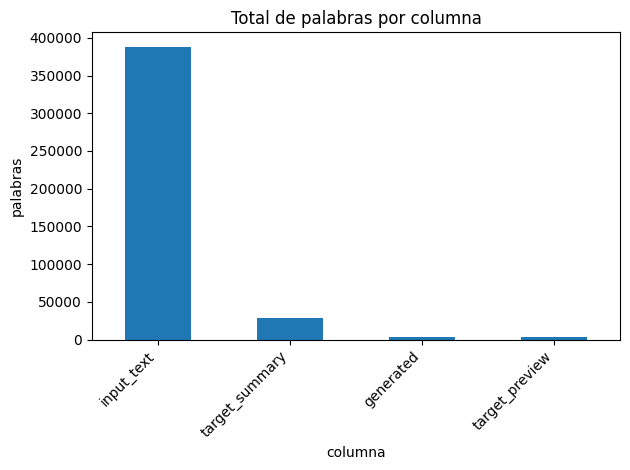

In [46]:
plt.figure()
totals.plot(kind="bar")
plt.title("Total de palabras por columna")
plt.ylabel("palabras")
plt.xlabel("columna")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Promedio de palabras por fila

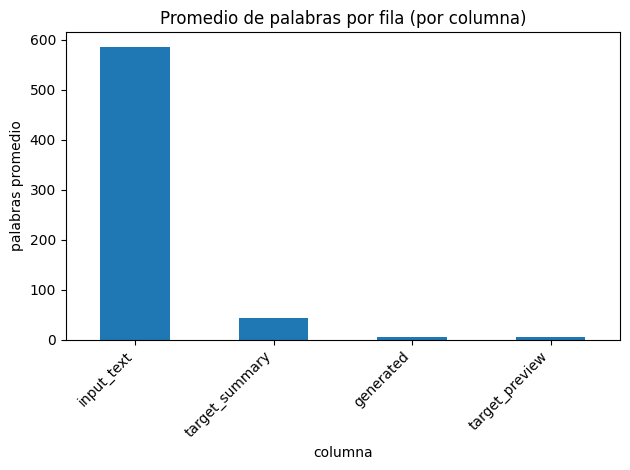

In [47]:
means = pd.Series({c: len_df[f"len_{c}"].mean() for c in cols}, name="mean_words").sort_values(ascending=False)

plt.figure()
means.plot(kind="bar")
plt.title("Promedio de palabras por fila (por columna)")
plt.ylabel("palabras promedio")
plt.xlabel("columna")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 2. Clustering 

In [25]:
# --- Rutas de Archivos (Ajustadas a la nueva estructura) ---
OUTPUT_DIR = Path.cwd() / "2_Modelos" / "clustering"
output_csv_path = OUTPUT_DIR / "clustering_results_consolidated.csv"
metrics_json_path = OUTPUT_DIR / "best_clustering_config_and_metrics.json"
analysis_path = OUTPUT_DIR / "cluster_analysis.json"
viz_path = OUTPUT_DIR / "clusters_visualization.png"


### Datos y Métricas

In [26]:
df_results = pd.read_csv(output_csv_path)
print(f"Cargados {len(df_results)} registros desde el CSV.")

with open(metrics_json_path, 'r') as f:
    best_model_data = json.load(f)
metrics = best_model_data['metrics']
print(f"Métricas cargadas para el mejor experimento: {best_model_data['experiment_key']}.")

Cargados 434 registros desde el CSV.
Métricas cargadas para el mejor experimento: distilbert_config_1.


In [27]:
# Extraer las columnas necesarias
cluster_labels = df_results['cluster_label'].values
embeddings_2d = df_results[['pca_dim_1', 'pca_dim_2']].values
df_with_labels = df_results # Alias para claridad


### Definición de stop words y función de limpieza

In [28]:
ENGLISH_STOP_WORDS = set(stopwords.words('english')) 

In [29]:

def clean_text_for_wordcloud(text: str) -> str:
    """Limpia el texto: minúsculas, elimina puntuación y números."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text) # Eliminar puntuación
    text = re.sub(r'\d+', '', text)      # Eliminar números
    return text

def get_top_keywords(text_list: list, n_keywords: int = 20) -> Counter:
    """Cuenta la frecuencia de palabras después de limpieza y stop word removal."""
    all_words = []
    STOP_WORDS_SET = ENGLISH_STOP_WORDS # Usamos las palabras clave en inglés
    for text in text_list:
        clean_t = clean_text_for_wordcloud(text)
        words = clean_t.split()
        for word in words:
            if word and word not in STOP_WORDS_SET and len(word) > 2:
                all_words.append(word)
    return Counter(all_words).most_common(n_keywords)



### Métricas

In [30]:
if metrics:
    print("\n" + "="*50)
    print("MÉTRICAS DEL MEJOR MODELO")
    print("="*50)
    print(f"Modelo / Config: {best_model_data['experiment_key']}")
    print(f"Silhouette Score: {metrics.get('silhouette_score', 'N/A'):.4f}")
    print(f"Davies-Bouldin Index: {metrics.get('davies_bouldin_score', 'N/A'):.4f}")
    print(f"Clusters Encontrados: {metrics.get('n_clusters', 'N/A')}")
    print(f"Puntos Ruido (#): {metrics.get('n_noise_points', 'N/A')}")


MÉTRICAS DEL MEJOR MODELO
Modelo / Config: distilbert_config_1
Silhouette Score: 0.3401
Davies-Bouldin Index: 1.1861
Clusters Encontrados: 5
Puntos Ruido (#): 268


### Análisis por cluster


ANÁLISIS DESCRIPTIVO POR CLUSTER

Outliers (Noticias únicas - Total: 268):
  1. Bruce Springsteen lent helping hand to director's family after Los Angeles wildfires
  2. Six protein-packed Trader Joe’s snacks dietitians recommend


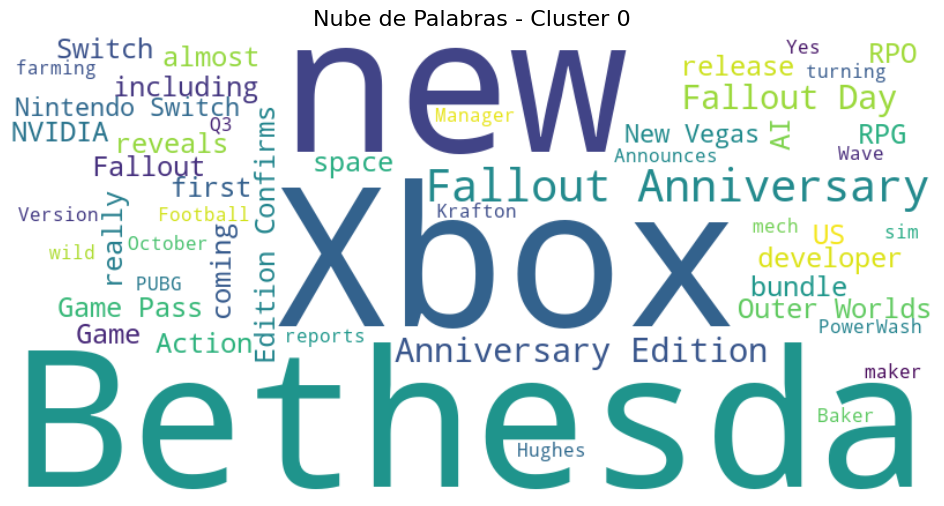


Cluster 0 (Tamaño: 20, 4.6%):
  Palabras Clave (Top 10): fallout, new, game, anniversary, edition, switch, xbox, bethesda, day, pass
  Fuentes principales: Windows Central, TechRadar, Space Daily
  Ejemplos Títulos: 1. Xbox Game Pass October Wave 2 is wild: The Outer Worlds 2, PowerWash 2, Football Manager 26, and a mech farming sim. Yes, really
                  2. Bethesda Announces Fallout 4 Anniversary Edition, Confirms Nintendo Switch 2 Version for 2026


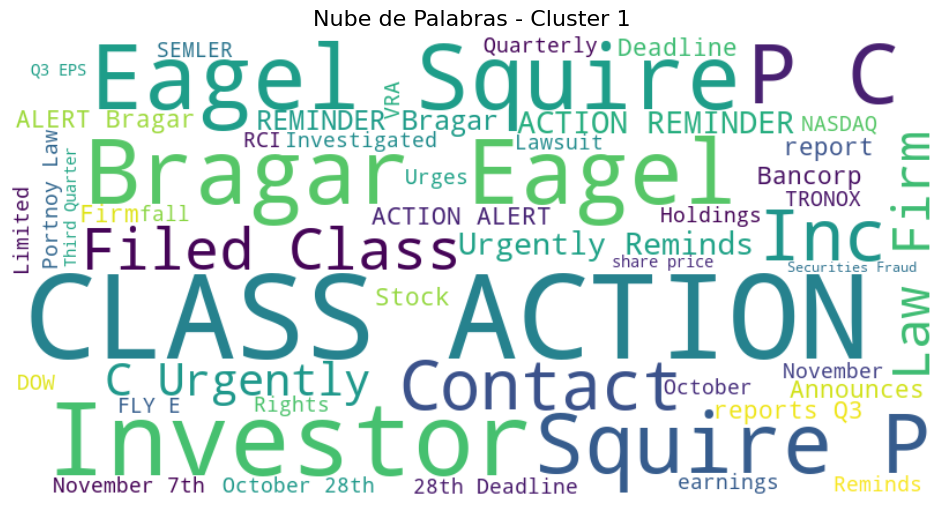


Cluster 1 (Tamaño: 29, 6.7%):
  Palabras Clave (Top 10): class, action, investors, firm, bragar, eagel, squire, reminds, inc, deadline
  Fuentes principales: GlobeNewswire, Thefly.com, Bitcoinist
  Ejemplos Títulos: 1. F5, Inc. Investigated by the Portnoy Law Firm
                  2. TRONOX CLASS ACTION ALERT: Bragar Eagel & Squire, P.C. Urgently Reminds Tronox Investors of the November 3rd Deadline in the Filed Class Action


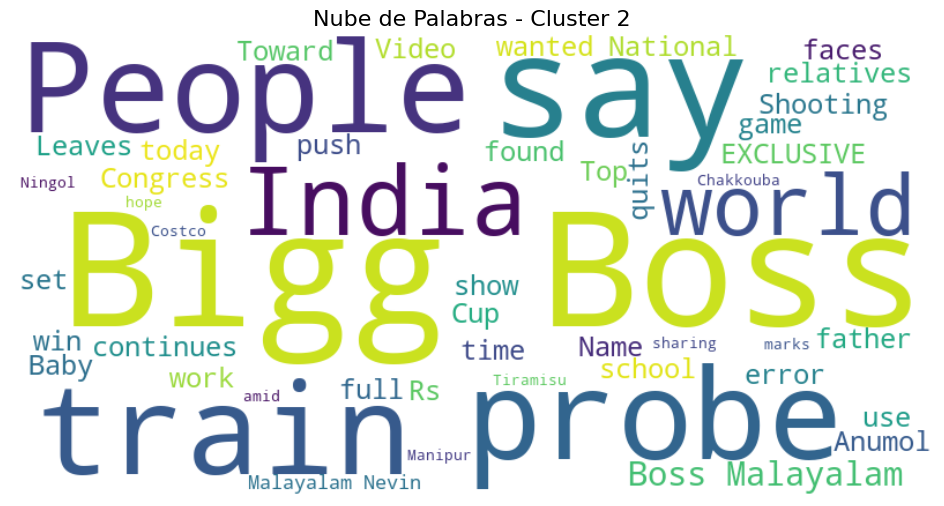


Cluster 2 (Tamaño: 42, 9.7%):
  Palabras Clave (Top 10): bigg, boss, people, says, probe, malayalam, india, world, found, error
  Fuentes principales: The Times of India, BBC News, The Daily Dot
  Ejemplos Títulos: 1. “I found my people”: People are sharing how they use Costco Tiramisu cups
                  2. Manipur marks Ningol Chakkouba amid hope & heartbreak for IDPs


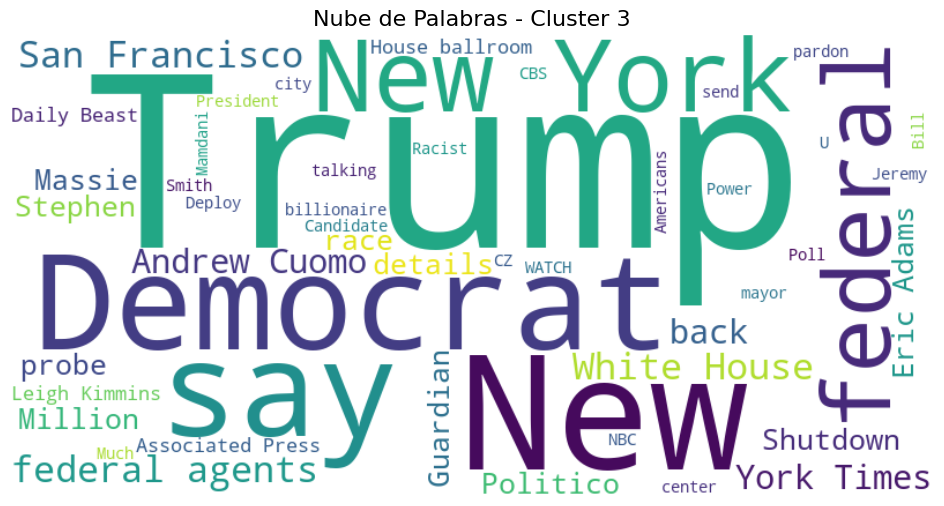


Cluster 3 (Tamaño: 54, 12.4%):
  Palabras Clave (Top 10): trump, federal, new, house, agents, mayor, says, york, news, white
  Fuentes principales: Memeorandum.com, Breitbart News, The Daily Caller
  Ejemplos Títulos: 1. Trump backs off planned surge of federal agents into San Francisco after talking to the mayor
                  2. U.S. Senate hopeful Graham Platner says he’s covered up his tattoo after learning it was a Nazi symbol: ‘I wanted this thing off my body’


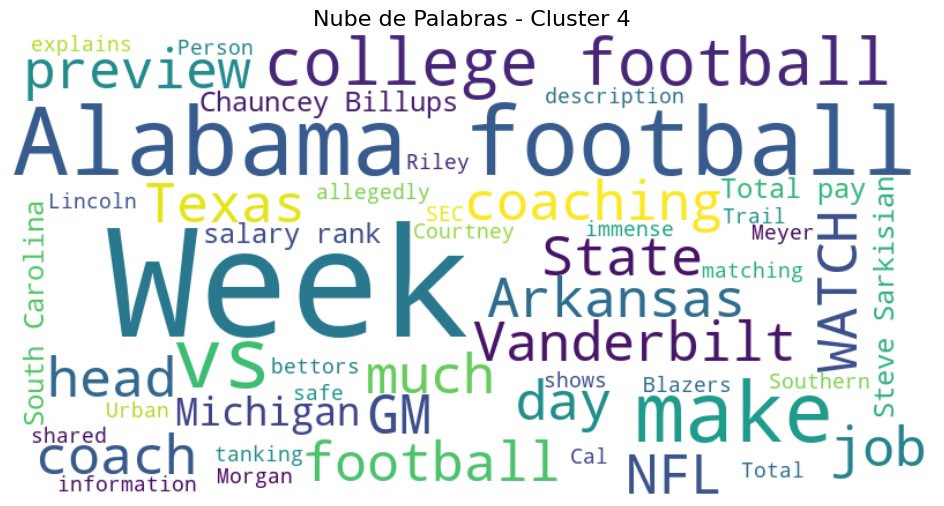


Cluster 4 (Tamaño: 21, 4.8%):
  Palabras Clave (Top 10): football, alabama, week, total, college, chauncey, billups, much, make, pay
  Fuentes principales: Sporting News, USA Today, CBS Sports
  Ejemplos Títulos: 1. Person matching Chauncey Billups' description allegedly shared Trail Blazers tanking information with bettors
                  2. How much does Alabama football GM Courtney Morgan make? Total pay, SEC salary rank


In [31]:
# --- 4. Análisis por Cluster y Generación de Nubes de Palabras ---

analysis = []
unique_labels = sorted(set(cluster_labels))

# Crear directorio para las nubes de palabras
wordcloud_dir = OUTPUT_DIR / "cluster_wordclouds"
wordcloud_dir.mkdir(exist_ok=True)

print("\n" + "="*50)
print("ANÁLISIS DESCRIPTIVO POR CLUSTER")
print("="*50)

# Inicializar WordCloud
# Usamos las stopwords en inglés para filtrar las nubes generadas con el contenido completo.
wc = WordCloud(
    background_color="white", 
    width=800, 
    height=400, 
    max_words=50, 
    stopwords=ENGLISH_STOP_WORDS 
)

# Colores para el gráfico PCA
n_clusters = len([l for l in unique_labels if l != -1])
colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters))
color_map = {l: colors[i] for i, l in enumerate([l for l in unique_labels if l != -1])}
color_map[-1] = 'black'

# Iterar sobre cada cluster
for cluster_id in unique_labels:
    cluster_docs = df_with_labels[df_with_labels['cluster_label'] == cluster_id]
    cluster_texts = cluster_docs['text'].tolist()
    
    # ----------------------------------------------------
    # A. Análisis de Outliers (-1)
    # ----------------------------------------------------
    if cluster_id == -1:
        if len(cluster_docs) > 0:
            print(f"\nOutliers (Noticias únicas - Total: {len(cluster_docs)}):")
            for i, (_, row) in enumerate(cluster_docs.head(2).iterrows(), 1):
                print(f"  {i}. {row['title']}")
        continue

    # ----------------------------------------------------
    # B. Análisis de Cluster Válido
    # ----------------------------------------------------
    
    # 1. Palabras Clave (Para el análisis descriptivo y JSON)
    top_keywords = get_top_keywords(cluster_texts, n_keywords=10)
    keyword_freq_dict = dict(top_keywords)
    top_keywords_text = ", ".join([k for k, v in top_keywords])
    
    # 2. Fuentes más frecuentes
    top_sources = cluster_docs['source'].value_counts().head(3)
    
    # 3. Preparar Texto Completo para WordCloud
    # Juntar todo el texto del cluster
    full_text_for_wc = " ".join(cluster_texts)
    
    # Generar Nube de Palabras
    try:
        if full_text_for_wc:
            # 💡 Cambio clave: usar wc.generate() con el texto completo
            wc.generate(full_text_for_wc) 
            wc_path = wordcloud_dir / f"cluster_{cluster_id}_wordcloud.png"
            wc.to_file(str(wc_path))
            
            # ----------------------------------------------------
            # PLOTTEO DE LA NUBE DE PALABRAS
            # ----------------------------------------------------
            plt.figure(figsize=(12,6))
            plt.imshow(wc, interpolation="bilinear")
            plt.axis("off")
            plt.title(f"Nube de Palabras - Cluster {cluster_id}", fontsize=16)
            plt.show() 
            plt.close() 
            # ----------------------------------------------------

        else:
            wc_path = None
    except Exception as e:
        print(f"Error al generar WordCloud para Cluster {cluster_id}: {e}")
        wc_path = None


    # Guardar la información para el JSON final
    cluster_info = {
        'cluster_id': int(cluster_id),
        'size': len(cluster_docs),
        'percentage': float(len(cluster_docs) / len(df_results) * 100),
        'top_keywords': keyword_freq_dict, # Usamos el top 10 para el JSON
        'sample_titles': cluster_docs['title'].head(3).tolist(),
        'top_sources': top_sources.to_dict(),
        'wordcloud_file': str(wc_path) if wc_path else 'N/A'
    }
    analysis.append(cluster_info)
    
    # Imprimir resumen
    print(f"\nCluster {cluster_id} (Tamaño: {len(cluster_docs)}, {cluster_info['percentage']:.1f}%):")
    print(f"  Palabras Clave (Top 10): {top_keywords_text}") # Indicamos que es el Top 10
    
    if not top_sources.empty:
        print(f"  Fuentes principales: {', '.join(top_sources.index.tolist())}")
    
    print(f"  Ejemplos Títulos: 1. {cluster_info['sample_titles'][0]}")
    if len(cluster_info['sample_titles']) > 1:
        print(f"                  2. {cluster_info['sample_titles'][1]}")

### Visualización PCA


VISUALIZACIÓN PCA 2D


/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_67930/79043300.py:17: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


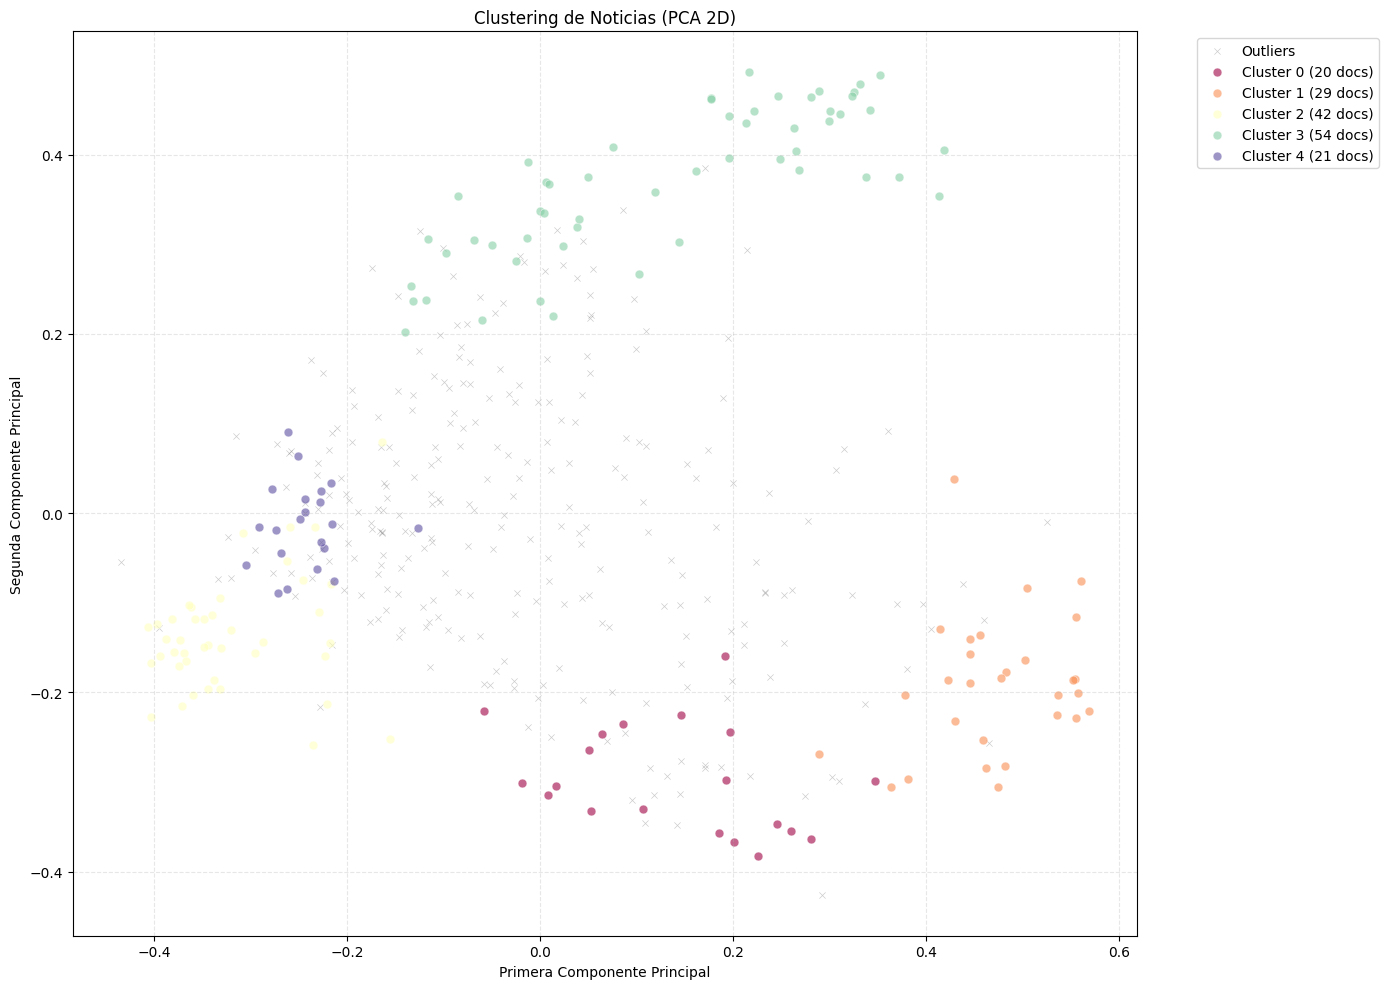

✓ Visualización de clusters (PCA) guardada en /Users/arielamishaancohen/Documents/UVG/Clases/Semestre 8 (2025)/Deep Learning/Tareas y Proyectos/Proyecto/2_Modelos/clustering/clusters_visualization.png


In [32]:

print("\n" + "="*50)
print("VISUALIZACIÓN PCA 2D")
print("="*50)

plt.figure(figsize=(14, 10))

# Usar los embeddings 2D ya exportados en el CSV
for label in unique_labels:
    mask = cluster_labels == label
    marker = 'x' if label == -1 else 'o'
    label_text = 'Outliers' if label == -1 else f'Cluster {label} ({np.sum(mask)} docs)'
    alpha = 0.2 if label == -1 else 0.6
    size = 20 if label == -1 else 40
    
    color = color_map.get(label, 'black')
    
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[color],
        label=label_text,
        marker=marker,
        alpha=alpha,
        s=size,
        edgecolors='white',
        linewidth=0.5
    )

plt.xlabel('Primera Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.title(f'Clustering de Noticias (PCA 2D)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

plt.savefig(viz_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Visualización de clusters (PCA) guardada en {viz_path}")
plt.close() 


## 3. Sentiment Analysis

### Análisis del dataset utilizado

In [2]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # solo letras y espacios
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arielamishaancohen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
sentiment_data = pd.read_csv("1_Data/processed/sentiment_data.csv")
sentiment_data.head()

,title,description,content,full_content,source,author,publishedAt,url,sentiment
0,Brockton mayoral race heats up as Derenoncourt...,Did a finalist to be Brockton's next mayor duc...,BROCKTON Did a finalist to be Brockton's next ...,BROCKTON — Did a finalist to be Brockton's nex...,Enterprise News,"Chris Helms, The Enterprise",2025-10-23T18:06:11Z,https://www.enterprisenews.com/story/news/poli...,neutral
1,Bruce Springsteen lent helping hand to directo...,"Bruce Springsteen, the legendary musician, dem...",<ul><li>News</li>\r\n<li>Bruce Springsteen len...,"Bruce Springsteen, the legendary musician, dem...",The Times of India,IANS,2025-10-23T18:05:51Z,https://timesofindia.indiatimes.com/entertainm...,neutral
2,Binance Founder Changpeng Zhao Receives Pardon...,U.S. President Donald Trump has granted Binanc...,U.S. President Donald Trump has granted Binanc...,Advertisement\n\nU.S. President Donald Trump h...,ZyCrypto,Brenda Ngari,2025-10-23T18:03:17Z,https://zycrypto.com/binance-founder-changpeng...,neutral
3,A Mandatory Paper Bag Fee May Be Coming to Phi...,Check phillymag.com each morning Monday throug...,"NewsPlus, Philly mob documentary makes a big s...",A Mandatory Paper Bag Fee May Be Coming to Phi...,phillymag.com,Victor Fiorillo,2025-10-23T18:03:12Z,https://www.phillymag.com/news/2025/10/23/plas...,neutral
4,Wilco and Billy Bragg to Perform Mermaid Avenu...,"""Mermaid Avenue Live"" is set to take place at ...",Wilco and Billy Bragg have announced they will...,Wilco and Billy Bragg have announced they will...,Consequence.net,Eddie Fu,2025-10-23T18:02:51Z,https://consequence.net/2025/10/wilco-billy-br...,neutral


In [4]:
sentiment_data['full_content'] = sentiment_data['full_content'].apply(clean_text)

In [5]:
# 2) INFORMACIÓN GENERAL
print("Número de filas y columnas:", sentiment_data.shape)
print("\nColumnas:", sentiment_data.columns.tolist())
print("\nTipos de datos:")
print(sentiment_data.dtypes)
print("\nValores nulos por columna:")
print(sentiment_data.isnull().sum())

Número de filas y columnas: (683, 9)

Columnas: ['title', 'description', 'content', 'full_content', 'source', 'author', 'publishedAt', 'url', 'sentiment']

Tipos de datos:
title           object
description     object
content         object
full_content    object
source          object
author          object
publishedAt     object
url             object
sentiment       object
dtype: object

Valores nulos por columna:
title             0
description       0
content           0
full_content      0
source            0
author          117
publishedAt       0
url               0
sentiment         0
dtype: int64


/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_66362/598873849.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=sentiment_data, palette=["red","gray","green"])


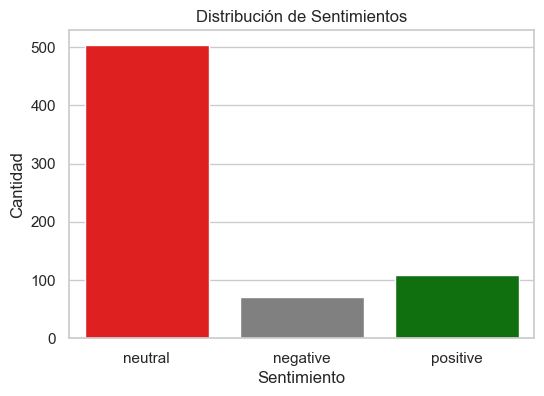

sentiment
neutral     0.737921
positive    0.158126
negative    0.103953
Name: proportion, dtype: float64


In [6]:
# 3) DISTRIBUCIÓN DE SENTIMIENTOS

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=sentiment_data, palette=["red","gray","green"])
plt.title("Distribución de Sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.show()

# Proporciones
print(sentiment_data["sentiment"].value_counts(normalize=True))

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_66362/2461955661.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_domains.values, y=top_domains.index, palette="viridis")


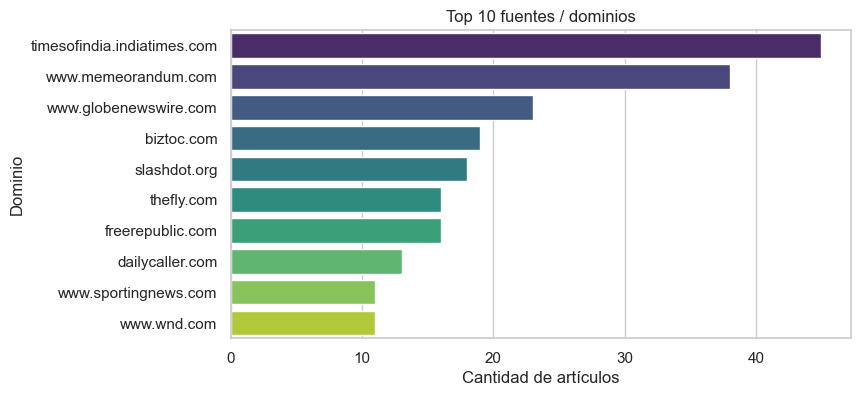

domain
timesofindia.indiatimes.com    45
www.memeorandum.com            38
www.globenewswire.com          23
biztoc.com                     19
slashdot.org                   18
thefly.com                     16
freerepublic.com               16
dailycaller.com                13
www.sportingnews.com           11
www.wnd.com                    11
Name: count, dtype: int64

In [8]:
# 4) FUENTES / URL
# Si tienes columna 'url', podemos ver top dominios
from urllib.parse import urlparse

if "url" in sentiment_data.columns:
    sentiment_data["domain"] = sentiment_data["url"].apply(lambda x: urlparse(str(x)).netloc)
    top_domains = sentiment_data["domain"].value_counts().head(10)
    
    plt.figure(figsize=(8,4))
    sns.barplot(x=top_domains.values, y=top_domains.index, palette="viridis")
    plt.title("Top 10 fuentes / dominios")
    plt.xlabel("Cantidad de artículos")
    plt.ylabel("Dominio")
    plt.show()
    
    display(top_domains)

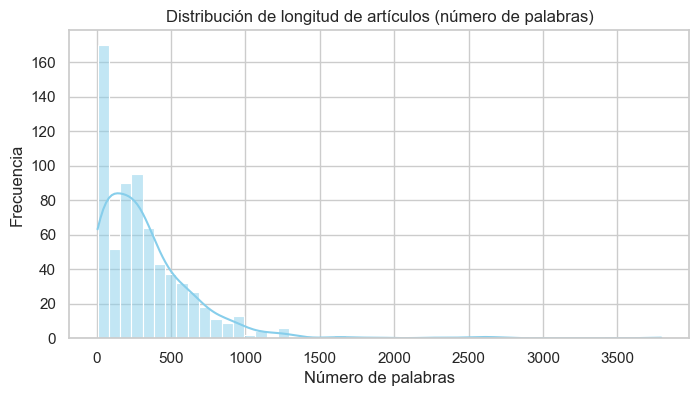

Estadísticas descriptivas de longitud de artículos:


count     683.000000
mean      334.855051
std       353.384745
min         7.000000
25%        88.000000
50%       257.000000
75%       459.000000
max      3795.000000
Name: content_len, dtype: float64

In [9]:
# 5) LONGITUD DE LOS TEXTOS
sentiment_data["content_len"] = sentiment_data["full_content"].fillna("").str.split().apply(len)

plt.figure(figsize=(8,4))
sns.histplot(sentiment_data["content_len"], bins=50, kde=True, color="skyblue")
plt.title("Distribución de longitud de artículos (número de palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

print("Estadísticas descriptivas de longitud de artículos:")
display(sentiment_data["content_len"].describe())

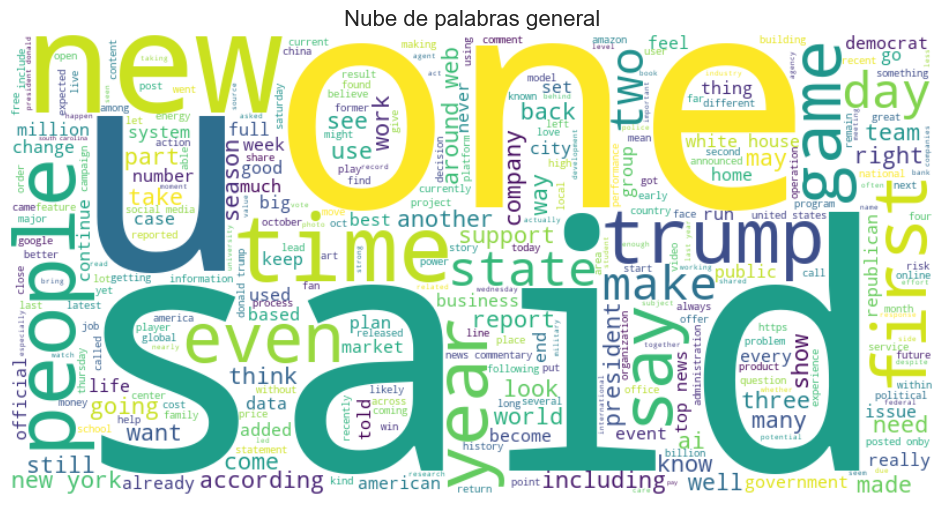

In [10]:
# 6) NUBE DE PALABRAS GENERAL
from wordcloud import WordCloud

all_text = " ".join(sentiment_data["full_content"].fillna("").astype(str))

wc = WordCloud(width=800, height=400, background_color="white", max_words=300).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras general", fontsize=16)
plt.show()

In [11]:
# 7) ARTÍCULOS MÁS LARGOS / CORTOS
print("5 artículos más largos:")
display(sentiment_data.nlargest(5, "content_len")[["title","content_len","sentiment"]])

print("\n5 artículos más cortos:")
display(sentiment_data.nsmallest(5, "content_len")[["title","content_len","sentiment"]])

5 artículos más largos:


,title,content_len,sentiment
221,(no subject),3795,negative
146,Your Evening Plans in EPCOT May Need to CHANGE...,2674,neutral
304,The mad king's digital killswitch,2609,neutral
234,8 Approaches To Make A Living In The Online Ga...,2498,positive
376,Daily Press Briefing by the Office of the Spok...,2263,neutral



5 artículos más cortos:


,title,content_len,sentiment
71,Λευκός Οίκος: Ο Τραμπ θα συναντήσει την επόμεν...,7,neutral
484,Στα άκρα η κόντρα ΗΠΑ-Ισραήλ: «Αν ο Νετανιάχου...,9,neutral
91,Federal immigration agents deploy tear gas in ...,12,neutral
92,Man dies in crash on Virginia’s I-264 highway ...,12,neutral
600,Trump backer Timothy Mellon identified as dono...,12,neutral


In [12]:
# 8) PALABRAS MÁS FRECUENTES POR SENTIMIENTO
from collections import Counter
import re

def top_words(df, label, col_text="full_content", n=20):
    text = " ".join(df[df["sentiment"] == label][col_text].fillna("").astype(str))
    # limpiar
    text = re.sub(r"\W+", " ", text.lower())
    words = text.split()
    counter = Counter(words)
    return counter.most_common(n)

for s in sentiment_data["sentiment"].unique():
    print(f"Top palabras en {s}:")
    display(top_words(sentiment_data, s))

Top palabras en neutral:


[('said', 956),
 ('news', 731),
 ('one', 691),
 ('new', 641),
 ('minutes', 576),
 ('like', 535),
 ('also', 512),
 ('trump', 472),
 ('time', 447),
 ('year', 431),
 ('us', 429),
 ('first', 400),
 ('would', 396),
 ('get', 378),
 ('two', 321),
 ('people', 319),
 ('world', 316),
 ('around', 289),
 ('state', 287),
 ('day', 286)]

Top palabras en negative:


[('new', 165),
 ('said', 155),
 ('com', 116),
 ('trump', 111),
 ('fallout', 107),
 ('news', 105),
 ('one', 83),
 ('like', 82),
 ('ai', 82),
 ('us', 81),
 ('would', 78),
 ('federal', 73),
 ('also', 72),
 ('free', 72),
 ('oct', 71),
 ('first', 67),
 ('power', 67),
 ('get', 63),
 ('game', 62),
 ('york', 62)]

Top palabras en positive:


[('trump', 184),
 ('said', 175),
 ('news', 164),
 ('one', 151),
 ('new', 130),
 ('people', 125),
 ('president', 123),
 ('like', 123),
 ('also', 116),
 ('house', 115),
 ('white', 103),
 ('time', 92),
 ('would', 91),
 ('top', 86),
 ('even', 85),
 ('us', 83),
 ('could', 80),
 ('online', 74),
 ('media', 74),
 ('company', 73)]

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_66362/1926717110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


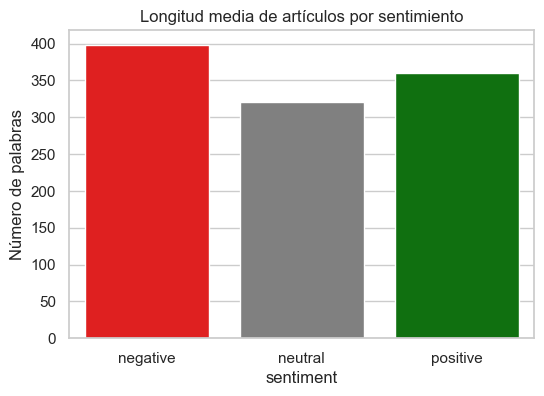

In [13]:
# 9) LONGITUD MEDIA DE ARTÍCULOS POR SENTIMIENTO
plt.figure(figsize=(6,4))
sns.barplot(
    x=sentiment_data.groupby("sentiment")["content_len"].mean().index,
    y=sentiment_data.groupby("sentiment")["content_len"].mean().values,
    palette=["red","gray","green"]
)
plt.title("Longitud media de artículos por sentimiento")
plt.ylabel("Número de palabras")
plt.show()

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_66362/3334435604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sentiment", y="content_len", data=sentiment_data, palette=["red","gray","green"])


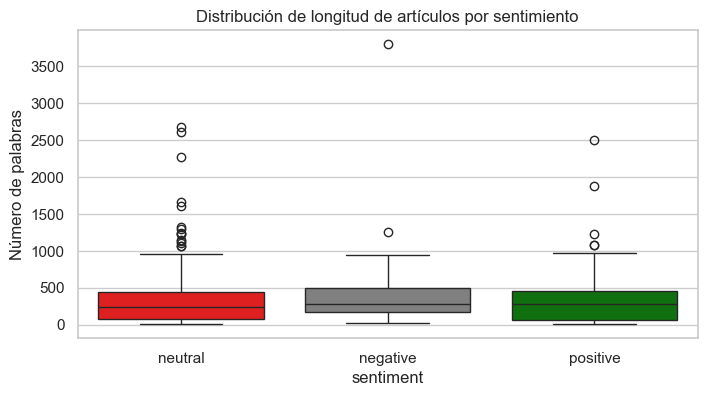

In [14]:
# 10) DISTRIBUCIÓN DE PALABRAS (BOXPLOT) POR SENTIMIENTO
plt.figure(figsize=(8,4))
sns.boxplot(x="sentiment", y="content_len", data=sentiment_data, palette=["red","gray","green"])
plt.title("Distribución de longitud de artículos por sentimiento")
plt.ylabel("Número de palabras")
plt.show()

In [16]:
# 11) ARTÍCULOS VACÍOS O MUY CORTOS
empty_or_short = sentiment_data[sentiment_data["content_len"] < 2]
print("Artículos vacíos o muy cortos (<5 palabras):", len(empty_or_short))
display(empty_or_short[["title","full_content","sentiment"]])

Artículos vacíos o muy cortos (<5 palabras): 0


,title,full_content,sentiment


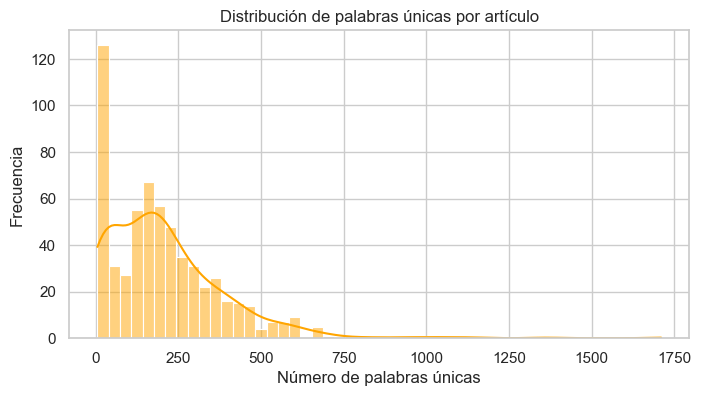

In [64]:
# 12) DISTRIBUCIÓN DE PALABRAS ÚNICAS POR ARTÍCULO
sentiment_data["unique_words"] = sentiment_data["full_content"].fillna("").apply(lambda x: len(set(x.split())))

plt.figure(figsize=(8,4))
sns.histplot(sentiment_data["unique_words"], bins=50, kde=True, color="orange")
plt.title("Distribución de palabras únicas por artículo")
plt.xlabel("Número de palabras únicas")
plt.ylabel("Frecuencia")
plt.show()

### Resultados

In [17]:
results_df = pd.read_csv("2_Modelos/sentiment/test_predictions.csv")
LABELS = ["negative", "neutral", "positive"]

In [18]:
y_true = results_df["true_label"]
y_pred = results_df["pred_label"]

print("=== MÉTRICAS GENERALES ===")
print(classification_report(y_true, y_pred, target_names=LABELS))

=== MÉTRICAS GENERALES ===
              precision    recall  f1-score   support

    negative       0.50      0.29      0.36         7
     neutral       0.75      0.90      0.82        51
    positive       0.25      0.09      0.13        11

    accuracy                           0.71        69
   macro avg       0.50      0.43      0.44        69
weighted avg       0.65      0.71      0.67        69



<Figure size 600x500 with 0 Axes>

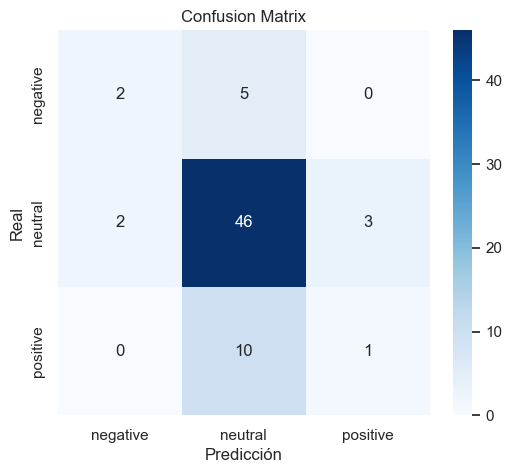

In [19]:
# === MATRIZ DE CONFUSIÓN ===
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()

In [20]:
errors_df = results_df[results_df["true_label"] != results_df["pred_label"]][
    ["text", "true_label", "pred_label"]
].copy()

# Contar errores por combinación
error_counts = (
    errors_df.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print("Errores más comunes:")
display(error_counts)

# Mostrar ejemplos aleatorios de errores
print("\nEjemplos de errores:")
display(errors_df.sample(min(5, len(errors_df)), random_state=42))

Errores más comunes:


,true_label,pred_label,count
3,positive,neutral,10
0,negative,neutral,5
2,neutral,positive,3
1,neutral,negative,2



Ejemplos de errores:


,text,true_label,pred_label
1,images ongoing destruction major section white...,neutral,positive
60,posts author added daily email digest homepage...,positive,neutral
56,win recently launched powerful gaming handheld...,positive,neutral
7,civil resistance work maga may say kings day h...,neutral,negative
38,veteran award winning journalist connie chung ...,positive,neutral


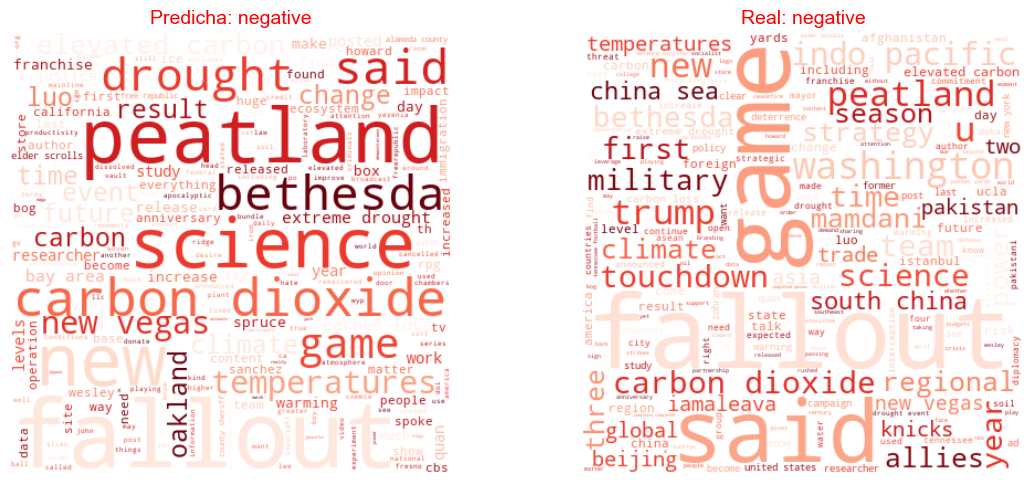

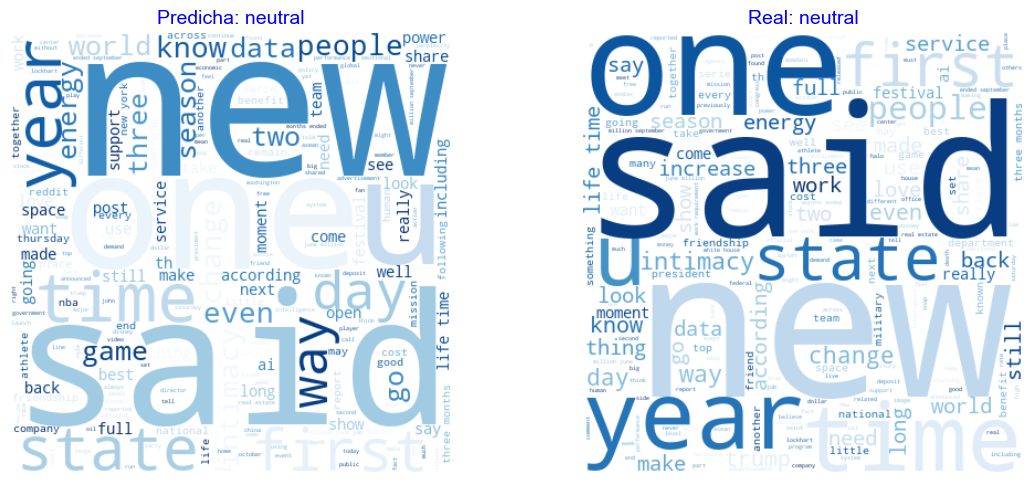

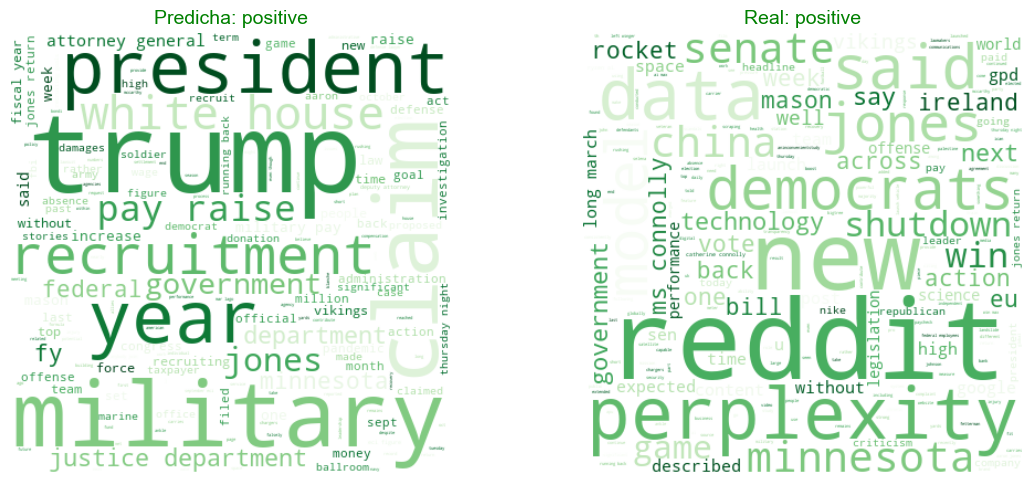

In [21]:
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def plot_wordcloud_side_by_side(results_df, label, col_text="text"):
    """
    Muestra nubes de palabras lado a lado:
    izquierda = predicha, derecha = real
    """
    cmap_dict = {"positive": "Greens", "neutral": "Blues", "negative": "Reds"}
    color_dict = {"positive": "green", "neutral": "blue", "negative": "red"}
    
    # Textos
    text_pred = " ".join(results_df[results_df["pred_label"] == label][col_text].astype(str))
    text_true = " ".join(results_df[results_df["true_label"] == label][col_text].astype(str))
    
    # Crear nubes
    wc_pred = WordCloud(width=400, height=400, background_color="white",
                        colormap=cmap_dict[label], max_words=200).generate(text_pred)
    wc_true = WordCloud(width=400, height=400, background_color="white",
                        colormap=cmap_dict[label], max_words=200).generate(text_true)
    
    # Subplots
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    axes[0].imshow(wc_pred, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title(f"Predicha: {label}", color=color_dict[label], fontsize=14)
    
    axes[1].imshow(wc_true, interpolation="bilinear")
    axes[1].axis("off")
    axes[1].set_title(f"Real: {label}", color=color_dict[label], fontsize=14)
    
    plt.tight_layout()
    plt.show()

# %%
# Mostrar nubes lado a lado para cada clase
for label in LABEL2ID.keys():
    plot_wordcloud_side_by_side(results_df, label)

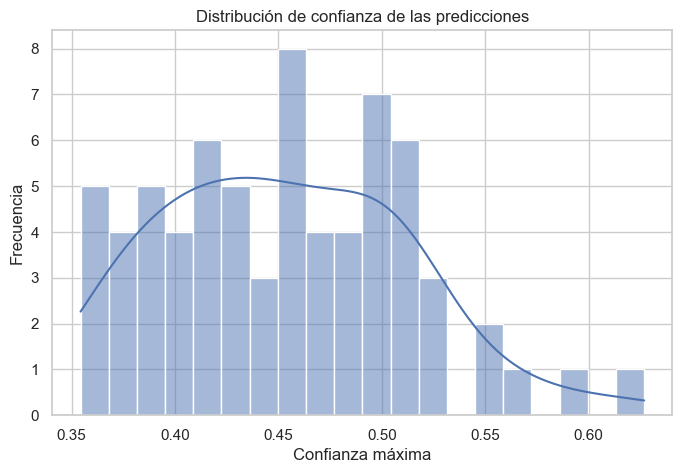

,text,true_label,pred_label,confidence
42,nba faces major scandal wire fraud probes targ...,negative,neutral,0.354363
35,article reviewed according science x editorial...,negative,negative,0.356181
23,iit ism dhanbad national techno mining fest kh...,positive,neutral,0.358562
36,halo studios rebuilding expanding story master...,neutral,neutral,0.364057
19,senate democrats rejected legislation thursday...,positive,neutral,0.365021
8,higher education increasingly attack students ...,neutral,neutral,0.373597
52,skip comments federal immigration operation ca...,neutral,negative,0.374225
30,get woman married former nba star chauncey bil...,neutral,neutral,0.377676
2,kevin hardy stateline org states rushing infor...,neutral,neutral,0.378072
9,long march rocket achieves breakthrough talles...,positive,neutral,0.383838


In [22]:
# === Crear columna de pred_probs ===
results_df["pred_probs"] = results_df[["prob_negative", "prob_neutral", "prob_positive"]].values.tolist()

# Calcular confianza máxima
max_probs = results_df["pred_probs"].apply(lambda x: max(x))

# === DISTRIBUCIÓN DE CONFIANZA ===
plt.figure(figsize=(8,5))
sns.histplot(max_probs, bins=20, kde=True)
plt.title("Distribución de confianza de las predicciones")
plt.xlabel("Confianza máxima")
plt.ylabel("Frecuencia")
plt.show()

# === EJEMPLOS DE BAJA CONFIANZA ===
low_conf_df = results_df[["text", "true_label", "pred_label"]].copy()
low_conf_df["confidence"] = max_probs

# Mostrar los 10 con menor confianza
display(low_conf_df.sort_values("confidence").head(10))

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_66362/1908856419.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


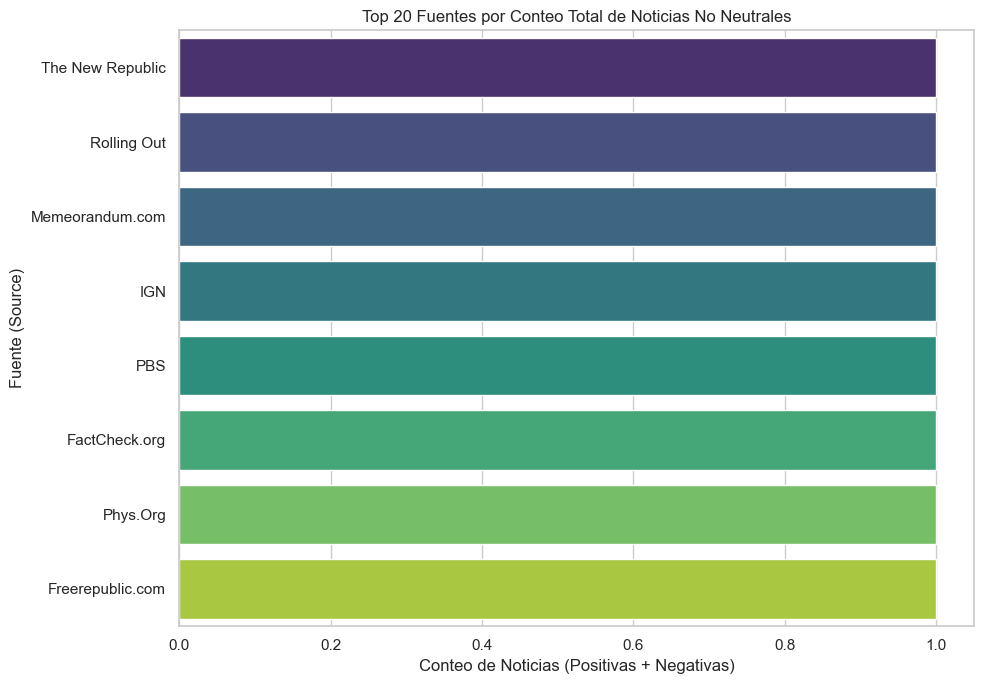

Mostrando las top 20 fuentes ordenadas por la cantidad de noticias no neutrales.


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # Añadir si no está importado, aunque plt es suficiente

# === ANÁLISIS POR FUENTE (NO NEUTRAL) Y GRÁFICO DESCENDENTE ===

# 1. Filtrar solo las predicciones 'negative' y 'positive' (No Neutrales)
df_no_neutral = results_df[
    results_df['pred_label'].isin(['negative', 'positive'])
].copy()

# 2. Contar el número total de noticias no neutrales por fuente
source_counts = df_no_neutral['source'].value_counts().reset_index()
source_counts.columns = ['source', 'total_no_neutral']

# 3. Seleccionar las top N fuentes (ej: las 20 más activas) para un gráfico legible
# Si hay demasiadas fuentes, seleccionar las 20 principales mejora la visualización.
N = 20
df_plot = source_counts.nlargest(N, 'total_no_neutral')

# 4. Visualización (Gráfico de Barras Simple)
plt.figure(figsize=(10, 7))
sns.barplot(
    x='total_no_neutral',
    y='source',
    data=df_plot,
    palette='viridis' # Usa una paleta de colores para mejor estética
)

plt.title(f'Top {N} Fuentes por Conteo Total de Noticias No Neutrales')
plt.xlabel('Conteo de Noticias (Positivas + Negativas)')
plt.ylabel('Fuente (Source)')
plt.tight_layout()
plt.show()

print(f"Mostrando las top {N} fuentes ordenadas por la cantidad de noticias no neutrales.")